## Time series 

### The dataset has information about the number of passengers of an airline company from US. The data was colleted monthly. 
### Interesting dataset to be analysed because there are all the elements of a time-series: trend, seasonality.

In [2]:
#Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from datetime import datetime

#convert pandas object for the use with matplotlib 
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [3]:
# Load dataset 
base = pd.read_csv('AirPassengers.csv')
base.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
base.shape

(144, 2)

In [5]:
# Checking dtypes 
print(base.dtypes)

Month          object
#Passengers     int64
dtype: object


In [6]:
# Convert feature dtype string to data-time format 
dateparse = lambda dates: datetime.strptime(dates, '%Y-%m')
base = pd.read_csv('AirPassengers.csv', parse_dates = ['Month'],
                   index_col = 'Month', date_parser = dateparse)
base

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3588\2415037141.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  base = pd.read_csv('AirPassengers.csv', parse_dates = ['Month'],


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [7]:
# Checking dataset index  (#Passengers) 
base.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [8]:
#creating a new element (time-serie)
ts = base['#Passengers']
ts

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, Length: 144, dtype: int64

In [9]:
# Visualing a specific index 
ts[1]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3588\3745279640.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ts[1]


118

In [10]:
# Visualizing by year and month 
ts['1949-02']

Month
1949-02-01    118
Name: #Passengers, dtype: int64

In [11]:
# Visualizing a specific date 
ts[datetime(1949,2,1)]

118

In [12]:
# Visualizing by intervals 
ts['1950-01-01':'1950-07-31']

Month
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
Name: #Passengers, dtype: int64

In [13]:
# Visualizing intervals without the start date 
ts[:'1950-07-31']

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
Name: #Passengers, dtype: int64

In [14]:
# Visualizing by year 
ts['1950']

Month
1950-01-01    115
1950-02-01    126
1950-03-01    141
1950-04-01    135
1950-05-01    125
1950-06-01    149
1950-07-01    170
1950-08-01    170
1950-09-01    158
1950-10-01    133
1950-11-01    114
1950-12-01    140
Name: #Passengers, dtype: int64

In [15]:
# Checking max value
ts.index.max()

Timestamp('1960-12-01 00:00:00')

In [16]:
# Checking mininmum value 
ts.index.min()

Timestamp('1949-01-01 00:00:00')

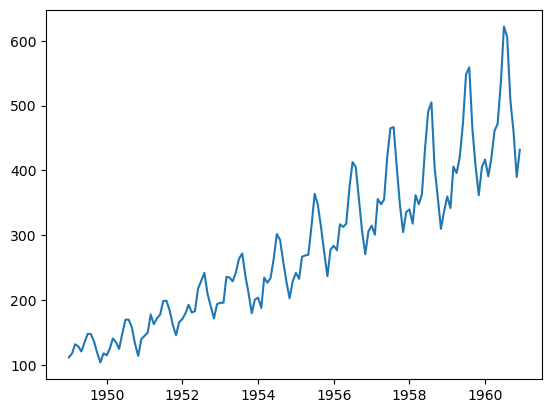

In [17]:
# Visualizing time-series 
plt.plot(ts)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3588\1798820867.py:2: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts_ano = ts.resample('A').sum()


Month
1949-12-31    1520
1950-12-31    1676
1951-12-31    2042
1952-12-31    2364
1953-12-31    2700
1954-12-31    2867
1955-12-31    3408
1956-12-31    3939
1957-12-31    4421
1958-12-31    4572
1959-12-31    5140
1960-12-31    5714
Freq: YE-DEC, Name: #Passengers, dtype: int64

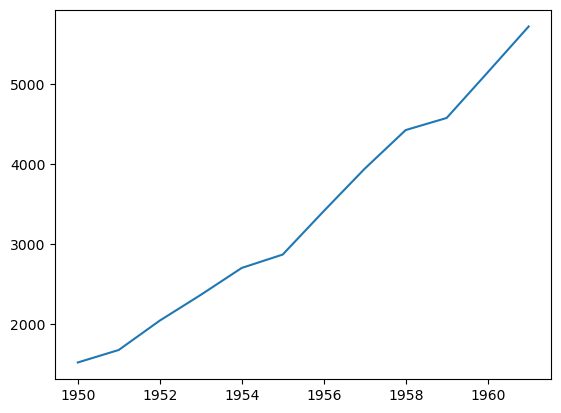

In [18]:
# Resample by year 
ts_ano = ts.resample('A').sum()
plt.plot(ts_ano)
ts_ano

We can see a smooth visualization of the dataset after being resampled by year using the function 'SUM'. It illustrates almost a straight line as the data were sumarized by year. The seasonality of the data has not shown in this graph because these elements are found in the month's values. 

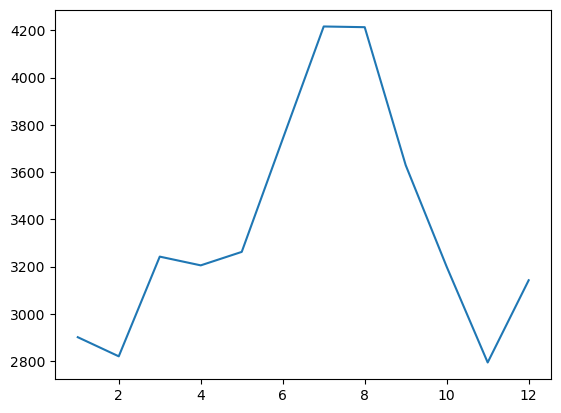

In [20]:
# Visualization by month 
ts_mes = ts.groupby([lambda x: x.month]).sum()
plt.plot(ts_mes)

This visualization above give us a summary of the time-series' behaviour throughout the year 

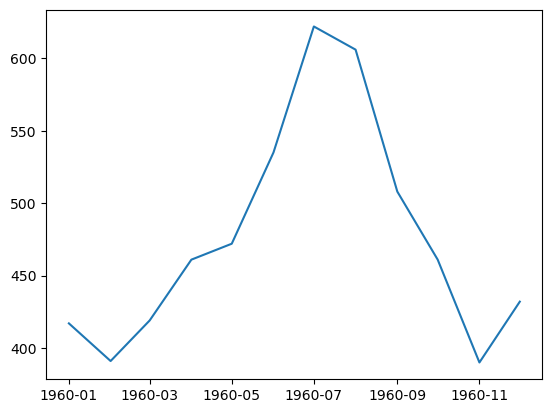

In [22]:
# Checking specific date 
ts_datas = ts['1960-01-01':'1960-12-01']
plt.plot(ts_datas)

In this grapgh we can see a similar behaviour of the data in the year 1960 with the data that was summarized and grouped by month on the previous visualization. 

It shows that the  whole time-series has a similar behaviour. After decomposition it can be seen with more clarity the frequency of seasonals effects and trends because these elements will be separated. 


## Decomposition 


In [25]:
#Create decomposition object. 
from statsmodels.tsa.seasonal import seasonal_decompose

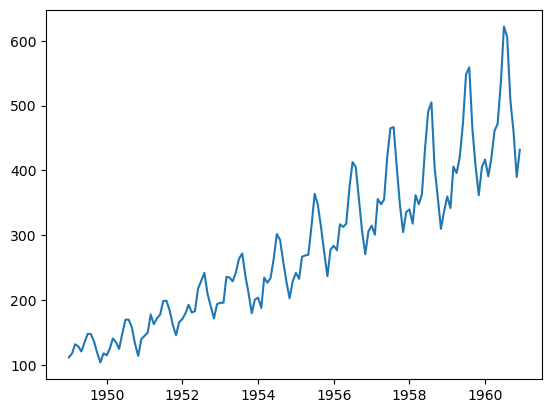

In [26]:
#Visualizaing time-series
plt.plot(ts)

In [27]:
# Decomposição da série temporal, criando uma variável para cada formato
decomposition = seasonal_decompose(ts)

In [28]:
#Trend
trend = decomposition.trend
trend

Month
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: trend, Length: 144, dtype: float64

In [29]:
#Seasonality 
seazonal = decomposition.seasonal
seazonal

Month
1949-01-01   -24.748737
1949-02-01   -36.188131
1949-03-01    -2.241162
1949-04-01    -8.036616
1949-05-01    -4.506313
                ...    
1960-08-01    62.823232
1960-09-01    16.520202
1960-10-01   -20.642677
1960-11-01   -53.593434
1960-12-01   -28.619949
Name: seasonal, Length: 144, dtype: float64

In [30]:
#error/residuals 
residual = decomposition.resid
residual

Month
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: resid, Length: 144, dtype: float64

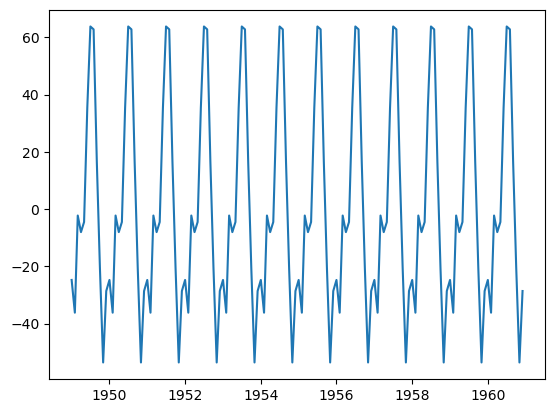

In [31]:
# Visualizing each format of time serie in a plot
plt.plot(seazonal)

### We can see that our seasonality has a constant frequency. We can see that the time serie elements seasonality, trend and residuals after the decomposition become more clearer. For example if we take the seasonality element, it clearly shows a regular pattern in the data with three different regular peaks. 

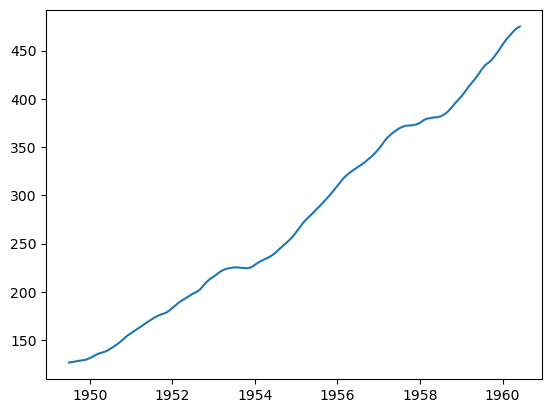

In [33]:
plt.plot(trend)

### The trend shows us almost a linear line with an increase tendency. We can see it more clearer after decomposition. 

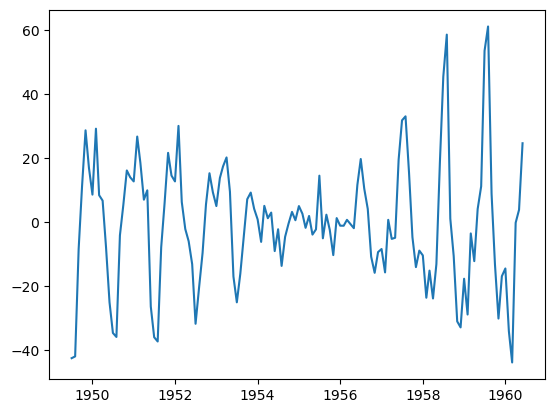

In [35]:
plt.plot(residual)

### The residuals are the observations are left after extracting trends and seasonality. These observations that cannot be explained mathematically. 


### Visualizing a plot with the original data and each element of the time series to compare the difference in another format. 

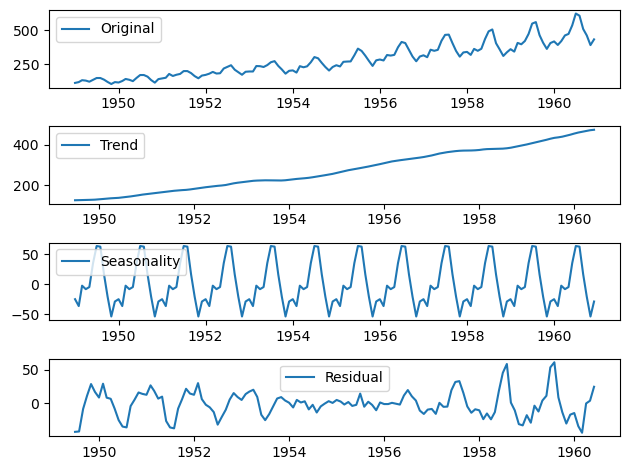

In [38]:
plt.subplot(4,1,1)
plt.plot(ts, label = 'Original')
plt.legend(loc = 'best')

# Visualização somente da tendência
plt.subplot(4,1,2)
plt.plot(trend, label = 'Trend')
plt.legend(loc = 'best')

# Visualização somente da sazonalidade
plt.subplot(4,1,3)
plt.plot(seazonal, label = 'Seasonality')
plt.legend(loc = 'best')

# Visualização somente do elemento aleatório
plt.subplot(4,1,4)
plt.plot(residual, label = 'Residual')
plt.legend(loc = 'best')
plt.tight_layout()

## Prediction of time-series 

In [40]:
pip install pmdarima

Note: you may need to restart the kernel to use updated packages.


In [41]:
#pip install pmdarima
from pmdarima.arima import auto_arima

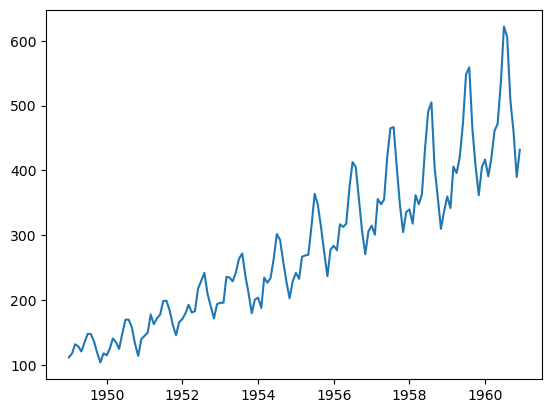

In [42]:
plt.plot(ts)

### Auto-ARIMA implemented

Normally it can be used default parameters. 

start_p, start_q, start_d = Auto-regressive parameters order, differentiating and move average 

start_P (capital P) = Auto-regressive to seasonal part 

max_p, max_q = maximum values that will be tested 

m = seasonal? 12 inform monthly seasonality 

seasonal=True - inform data has seasonality 

trace=True - to create an exit no console 

stepwise = Should be implemented an Optimization method?
The search for the best model can be faster, but that does not mean the best model will be found. 


### AIC 

Metric to evaluate how the model performs. The aim is to inimize the AIC. The lowest the AIC, the better the model. 

In [45]:
stepwise_model = auto_arima(ts, start_p=1,start_q=1,start_d= 0, start_P=0, max_p=6, max_q=6, m=12, seasonal=True, trace=True, stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=1022.896, Time=0.27 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.17 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.18 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=1019.239, Time=0.29 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=1.93 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1020.493, Time=0.38 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=1032.120, Time=0.18 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=1021.120, Time=0.39 sec
 ARIMA(1,1,1)(2,1,0)[12]             : AIC=1021.032, Time=0.84 sec
 ARIMA(0,1,1)(2,1,0)[12]             : AIC=1019.178, Time=0.37 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=1020.425, Time=0.13 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=inf, Time=1.70 sec
 ARIMA(0,1,1)(1,1,1)[12]     

In [46]:
print(stepwise_model.aic())

1019.1780567487319


### stepwise True - #1019.1780567487502

### Training and test 

training - The model will be trained with the train data set. ['1949-01-01':'1959-12-01']

test - last year 1960 (whole year). 

In [49]:
train = ts.loc['1949-01-01':'1959-12-01']
test = ts.loc['1960-01-01':]

In [50]:
train

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1959-08-01    559
1959-09-01    463
1959-10-01    407
1959-11-01    362
1959-12-01    405
Name: #Passengers, Length: 132, dtype: int64

In [51]:
test

Month
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, dtype: int64

In [52]:
stepwise_model.fit(train)

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(2, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

### Prediction for the 12 months 

So, the model is predicting the same period that already has happened (the data we selected as Test)

In [54]:
future_forecast = stepwise_model.predict(n_periods=12)

In [55]:
future_forecast

1960-01-01    421.153373
1960-02-01    401.605753
1960-03-01    462.083577
1960-04-01    450.826710
1960-05-01    475.124360
1960-06-01    529.774275
1960-07-01    605.741141
1960-08-01    618.774117
1960-09-01    516.769043
1960-10-01    463.571231
1960-11-01    417.168988
1960-12-01    458.049056
Freq: MS, dtype: float64

In [56]:
future_forecast = pd.DataFrame(future_forecast,index = test.index,columns=["#Passengers"])

### Visualizing the test data (what actual happened) with the AUTO-ARIMA model prediction. 

Remember that the model learned with the train data from 1949 to 1959, 10 years of passengers' data. 

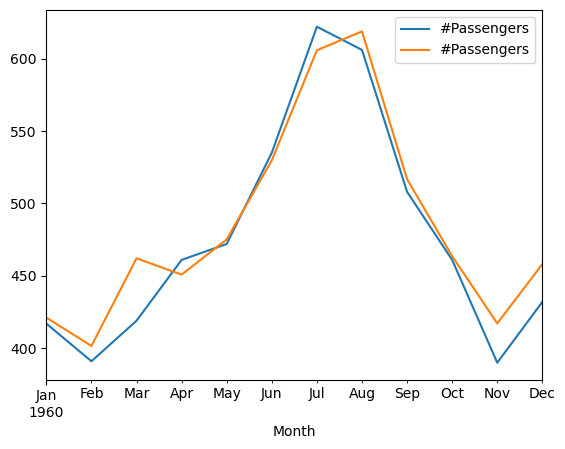

In [58]:
#blue=test, orange= forecast
pd.concat([test,future_forecast],axis=1).plot();

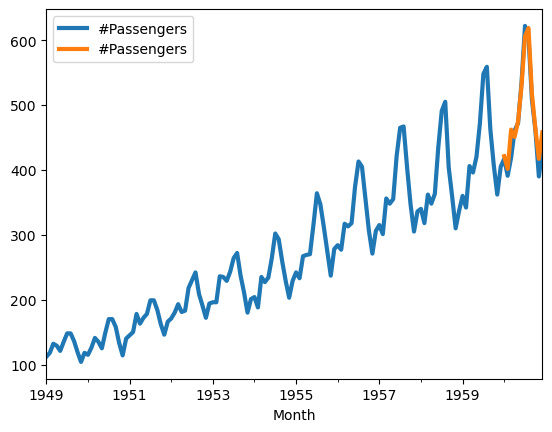

In [59]:
pd.concat([ts,future_forecast],axis=1).plot(linewidth=3);